# ML06 - Machine Learning Fall 2024

- **Name:** `Mohammad Ali Olama`
- **Student ID:** `####`

---

### Submission Deadline: **January 10th, 2025**
#### Submit your assignment via Microsoft Teams.
#### File Naming Format: `ML06_LASTNAME_STUDENTID.ipynb`

---

### *Instructions for Completing the Problem Set:*

- The problem set includes both coding and written response questions. For coding tasks, complete all code blocks marked with `YOUR CODE HERE`.
  
- For written answers, replace the placeholder text `[Your answer here]`  with your response.

- You are allowed to use AI assistance for this assignment, but you must fully disclose any AI usage in the final cell of this notebook. Please include any prompts you used with AI tools. Failure to disclose AI assistance will result in a zero on the assignment, as we have tools in place to detect such cases. We encourage transparency—there are no restrictions on AI use, so there's no reason not to be honest!

- **(Important Note) : Please do not submit a Colab link for your assignment answers. Instead, make sure to download your work as a `.ipynb` file and attach it directly to your submission. This is essential for proper grading and review.**

**<font face="Courier New" color="Red" size="+2">Attention: Questions 4 and
5 are optional and they have extra points!**

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 1: Basics of Neural Networks (14 points)</font>**

#### <font face="Verdana" color="green" size="+2">**1.1 Perceptron vs. Logistic Regression**
</font>

In this part, you will explore the differences between a perceptron and logistic regression.

#### <font face="Verdana" color="green" size="+2">**1.1.1**
 Using sklearn, implement and train both a perceptron and a logistic regression model on a binary classification dataset generated by `make_blobs`.</font>


  - Compare their decision boundaries using visualizations.
  - Analyze the performance of both models using accuracy and a confusion matrix.
  - **To generate data, consider 200 samples with 0.2 noise**



In [ ]:
!pip install tensorflow==2.15.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.1 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.0
    Uninstalling wrapt-1.17.0:
      Successfully uninstalled wrapt-1.17.0
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: tensorboard
    Found existing installatio

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from keras.callbacks import ModelCheckpoint
from keras.datasets import fashion_mnist
from keras.layers import Dense, Input, Dropout, Conv2D, AveragePooling2D, MaxPooling2D, Flatten
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical  # Import to_categorical
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout  # Import Activation and Dropout
from tensorflow.keras.models import load_model
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Activation
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.initializers import he_normal
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
# Generate data
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42, cluster_std=0.2)  # Adjust cluster_std for noise

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [ ]:
# Perceptron
perceptron = Perceptron(random_state=42)
perceptron.fit(X_train, y_train)
y_pred_perceptron = perceptron.predict(X_test)

# Logistic Regression
logistic = LogisticRegression(random_state=42)
logistic.fit(X_train, y_train)
y_pred_logistic = logistic.predict(X_test)

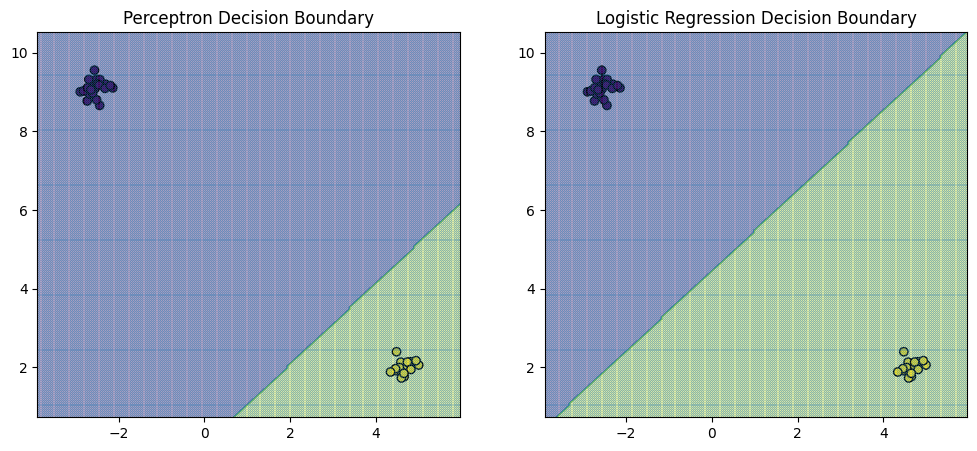

In [ ]:
# Decision Boundary Visualization

#Use the numpy function meshgrid to generate a dense grid of points within this range.
# Use the model to make predictions at these points and reshape the predictions to the same shape as the grid.
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.scatter(xx, yy , s=0.05)
    return xx , yy

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_decision_boundary(perceptron, X_test, y_test)
plt.title("Perceptron Decision Boundary")

plt.subplot(1, 2, 2)
xx , yy = plot_decision_boundary(logistic, X_test, y_test)
plt.title("Logistic Regression Decision Boundary")
plt.show()


The difference in decision boundaries arises from how the algorithms work:

Perceptron: It uses a hard threshold to classify points and only updates weights when misclassifications occur. The resulting decision boundary is linear and strictly separates the classes if they are linearly separable.

Logistic Regression: It optimizes the likelihood of class probabilities using a sigmoid function, creating a probabilistic model. Its decision boundary is also linear but aims to maximize the margin and minimize classification uncertainty rather than strictly separating classes.

Hence, the perceptron boundary is rigid, while the logistic regression boundary reflects probabilistic optimization.

Perceptron Accuracy:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Perceptron Confusion Matrix:


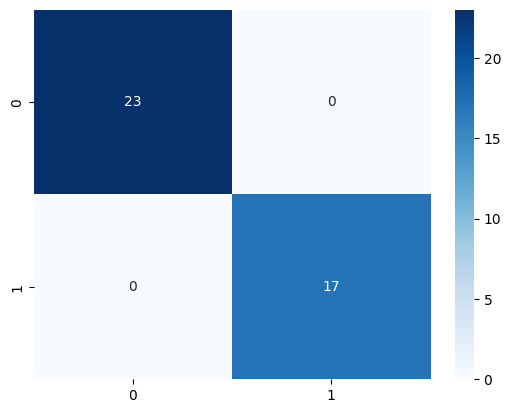

In [ ]:
# Evaluation
print("Perceptron Accuracy:", classification_report(y_test, y_pred_perceptron))
print("\nPerceptron Confusion Matrix:")
cm_perceptron = confusion_matrix(y_test, y_pred_perceptron)
sns.heatmap(cm_perceptron, annot=True, fmt='d', cmap='Blues')
plt.show()



Logistic Regression Accuracy:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Logistic Regression Confusion Matrix:


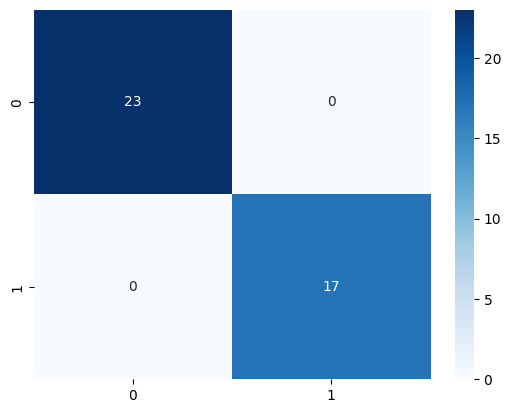

In [ ]:
print("\nLogistic Regression Accuracy:", classification_report(y_test, y_pred_logistic))
print("\nLogistic Regression Confusion Matrix:")
cm_logistic = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues')
plt.show()

#### <font face="Verdana" color="green" size="+2">**1.1.2**
- How do the decision boundaries of the two models differ?
- When would logistic regression be preferred over a perceptron?
</font>

### **1. How do the decision boundaries of the two models differ?**
- **Perceptron:**
  - A perceptron uses a hard threshold function to classify data points, resulting in a **linear decision boundary** that perfectly separates the data if it is linearly separable.
  - It does not handle non-separable data well and may fail to converge.

- **Logistic Regression:**
  - Logistic regression also produces a **linear decision boundary**, but it uses a sigmoid function to handle probabilities, making it robust to noisy or overlapping data.
  - Its decision boundary minimizes log-loss, leading to a more balanced boundary even for non-separable data.

**Summary:**  
Both produce linear boundaries, but logistic regression adjusts for overlapping/noisy data, while the perceptron assumes perfect separability.

---

### **2. When would logistic regression be preferred over a perceptron?**
- **Non-separable Data:** Logistic regression handles data that is not perfectly separable, unlike the perceptron.  
- **Overlapping Classes:** It is better for data with overlapping distributions.  
- **Noise:** More robust to noisy data points.  
- **Probabilistic Outputs:** Logistic regression provides probabilities, useful in decision-making.  
- **Convergence:** Logistic regression guarantees convergence, while the perceptron may oscillate on non-separable data.

#### <font face="Verdana" color="green" size="+2">**1.2 Training an MLP with Keras**
</font>

In this part, you will train and evaluate a simple Multi-Layer Perceptron (MLP) for a classification task.

#### <font face="Verdana" color="green" size="+2">**1.2.1**

- Use the dataset from the previous part
- Preprocess the dataset (e.g., scaling features).
- Build and train an MLP using the Keras Sequential API with:
 - One hidden layer with 16 neurons and ReLU activation.
    - A sigmoid activation function in the output layer.
    - Evaluate the model's performance using accuracy and a confusion matrix.</font>

Epoch 1/100
4/4 [==============================] - 2s 81ms/step - loss: 0.6299 - accuracy: 0.5078 - val_loss: 0.7097 - val_accuracy: 0.3750
Epoch 2/100
4/4 [==============================] - 0s 24ms/step - loss: 0.6085 - accuracy: 0.5078 - val_loss: 0.6869 - val_accuracy: 0.3750
Epoch 3/100
4/4 [==============================] - 0s 23ms/step - loss: 0.5883 - accuracy: 0.5078 - val_loss: 0.6646 - val_accuracy: 0.3750
Epoch 4/100
4/4 [==============================] - 0s 21ms/step - loss: 0.5682 - accuracy: 0.5078 - val_loss: 0.6431 - val_accuracy: 0.3750
Epoch 5/100
4/4 [==============================] - 0s 21ms/step - loss: 0.5493 - accuracy: 0.5078 - val_loss: 0.6223 - val_accuracy: 0.3750
Epoch 6/100
4/4 [==============================] - 0s 28ms/step - loss: 0.5306 - accuracy: 0.5078 - val_loss: 0.6023 - val_accuracy: 0.3750
Epoch 7/100
4/4 [==============================] - 0s 45ms/step - loss: 0.5131 - accuracy: 0.5078 - val_loss: 0.5830 - val_accuracy: 0.3750
Epoch 8/100
4/4 [===

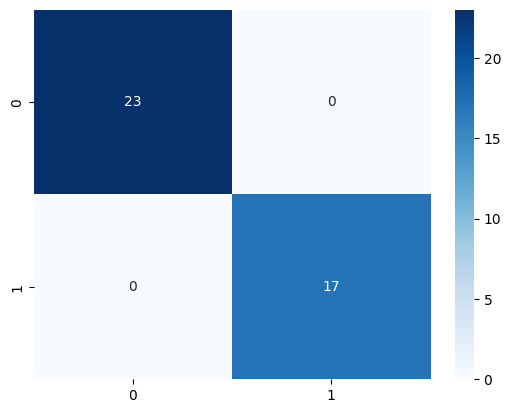

MLP Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        17

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [ ]:

# Scale the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build the MLP model
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(2,))) # Input shape matches the number of features
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1, validation_split=0.2) # Set verbose to 0 to suppress training output


# Evaluate the model
_, accuracy = model.evaluate(X_test, y_test, verbose=0)
y_pred_mlp = (model.predict(X_test) > 0.5).astype("int32") # Convert probabilities to binary predictions

print(f"MLP Accuracy: {accuracy}")
print("\nMLP Confusion Matrix:")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues')
plt.show()

print("MLP Classification Report:")
print(classification_report(y_test, y_pred_mlp))

Text(0, 0.5, 'Accuracy')

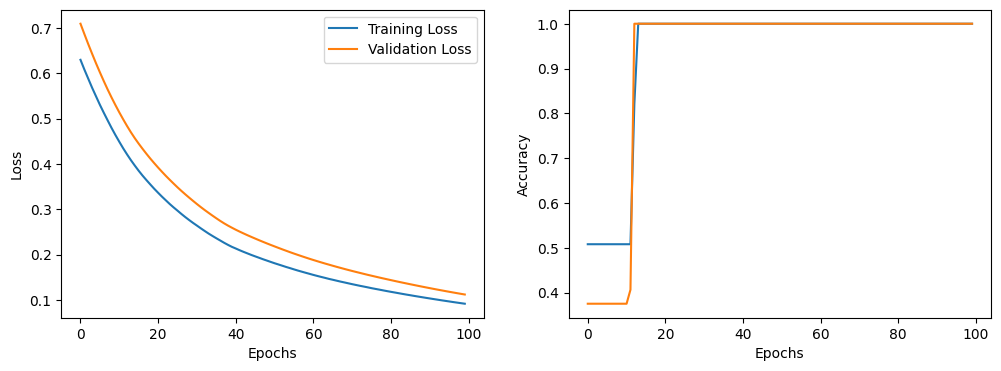

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

#### <font face="Verdana" color="green" size="+2">**1.2.2**
- What is the role of the activation function in the hidden and output layers?
- How does scaling the input features affect model training?</font>

### **1. What is the role of the activation function in the hidden and output layers?**
- **Hidden Layers:**
  - Activation functions introduce non-linearity into the model, enabling it to learn complex patterns and relationships in the data.
  - Without activation functions, the model would behave like a linear model, regardless of the number of layers.

- **Output Layer:**
  - The activation function determines the format of the model's output:
    - **Sigmoid:** Used for binary classification, outputs probabilities between 0 and 1.
    - **Softmax:** Used for multi-class classification, outputs probabilities for each class.
    - **Linear:** Common for regression tasks, outputs continuous values.

---

### **2. How does scaling the input features affect model training?**
- **Improves Convergence Speed:**
  - Scaling ensures that all input features are on a similar scale, preventing larger-valued features from dominating and improving the gradient descent's efficiency.

- **Avoids Numerical Instability:**
  - Features with vastly different scales can cause numerical instability or poor optimization performance.

- **Reduces Bias in Weight Updates:**
  - Scaling prevents features with large values from disproportionately affecting weight updates, leading to better generalization.


<hr>





### **<font face="Courier New" color="blue" size="+3">Question 2: Concepts of MLP (8 points)</font>**

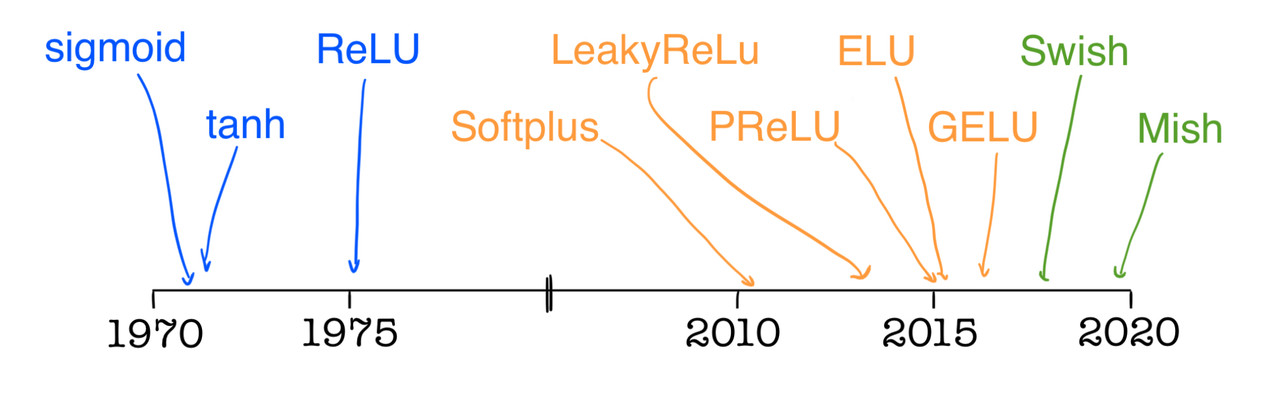

#### <font face="Verdana" color="green" size="+2">**2.1**
From your perspective, which of the activation functions explained in the slides is more commonly used in deep networks? Explain your reason for choosing it.
</font>

### **Most Commonly Used Activation Function in Deep Networks**
The **ReLU (Rectified Linear Unit)** is the most commonly used activation function in deep networks.

### **Reasons for Choosing ReLU:**
1. **Non-linearity and Simplicity:**
   - ReLU introduces non-linearity, which is essential for learning complex patterns, yet it is computationally simple ($f(x) = \max(0, x)$).

2. **Efficient Training:**
   - Unlike sigmoid or tanh, ReLU does not saturate for positive inputs, reducing the vanishing gradient problem and allowing faster convergence during training.

3. **Sparse Activations:**
   - ReLU outputs zero for negative inputs, leading to sparsity in activations. This sparsity can make the network more efficient and reduce overfitting.


**Conclusion:** ReLU is favored for its efficiency, reduced gradient issues, and suitability for deep networks, making it the default choice in most deep learning applications.

![Image](https://miro.medium.com/v2/resize:fit:828/format:webp/1*RD0lIYqB5L2LrI2VTIZqGw.png)

#### <font face="Verdana" color="green" size="+2">**2.2**
Explain the issue of vanishing and exploding gradients, and describe how the choice of activation functions can influence the likelihood of these problems. </font>

### Vanishing and Exploding Gradients

- **Vanishing Gradients**: Occurs when gradients become very small as they are propagated through deep networks, causing slow or halted learning. This is common with **sigmoid** and **tanh** activation functions, which squash values into small ranges, leading to small gradients.

- **Exploding Gradients**: Occurs when gradients grow exponentially during backpropagation, causing instability in the network. This can happen with deep networks, especially when using poorly initialized weights.

### Influence of Activation Functions

- **Sigmoid and Tanh**: Prone to vanishing gradients due to small derivatives for extreme input values.
- **ReLU**: Reduces vanishing gradients (derivative is 0 or 1), but can lead to "dying neurons" (zero gradients) if the input is negative.
- **Leaky ReLU**: A variant of ReLU that allows a small gradient for negative

### Mitigation Techniques
- **Gradient Clipping**: Limits gradients to avoid explosions.
- **Residual Networks (ResNets)**: Skip connections help gradients flow more easily through deep networks.

![Image2](https://dustinstansbury.github.io/theclevermachine/assets/images/a-gentle-introduction-to-neural-networks/common_activation_functions.png)


#### <font face="Verdana" color="green" size="+2">**2.3**
What is the advantage of using deeper MLP networks? Do deeper networks always produce better results compared to shallower ones?
</font>

### Advantages of Deeper MLP Networks

1. **Learning Complex Representations**: Deeper networks capture hierarchical features, enabling them to model complex patterns in data.
2. **Increased Expressive Power**: They can approximate more complex functions, making them effective for difficult tasks.
3. **Better Generalization**: With proper regularization, deeper networks can generalize well to unseen data, especially with large datasets.

### Do Deeper Networks Always Produce Better Results?

No, deeper networks do not always outperform shallower ones. Key factors include:

1. **Overfitting**: Deeper networks are more prone to overfitting without proper regularization.
2. **Training Difficulties**: Issues like vanishing/exploding gradients can hinder training effectiveness.
3. **Computational Cost**: Deeper networks demand more resources and longer training times.

<hr>





### **<font face="Courier New" color="blue" size="+3">Question 3:  Classifying Images from the FashionMNIST Dataset (30 points)</font>**

You are tasked with building and training a Multilayer Perceptron (MLP) model to classify images from the FashionMNIST dataset. The dataset contains 60,000 grayscale training images and 10,000 test images, each of size
$28 × 28 × 28$ pixels, across 10 classes. Load the dataset using `tf.keras.datasets.fashion_mnist.load_data()`. Follow the steps below:



#### <font face="Verdana" color="green" size="+2">**3.1. Data Preparation and Exploration**
- Load the FashionMNIST dataset and split it into X_train, y_train, X_test, and y_test.
- Create a dictionary mapping class labels (0 to 9) to their corresponding names (e.g., T-shirt, Trouser).
- Display at least 5 examples of the training data along with their labels using matplotlib. </font>



4422102/4422102 [==============================] - 0s 0us/step


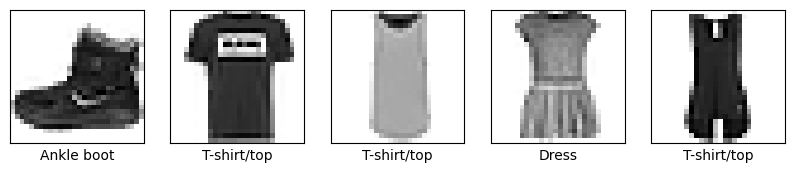

In [ ]:
# Load the FashionMNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Create a dictionary mapping class labels to names
labels_map = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

# Display examples of the training data
plt.figure(figsize=(10, 10))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(labels_map[y_train[i]])
plt.show()

#### <font face="Verdana" color="green" size="+2">**3.2. Data Preprocessing**
- Reshape the input so that each $28 × 28 × 28$ image becomes a single 784-dimensional vector.
- Normalize the pixel values to the range [0, 1].
- Convert the class labels to one-hot encoded vectors. </font>



In [ ]:
X_train.shape

(60000, 28, 28)

In [ ]:
# Reshape the input data
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

# Normalize the pixel values
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

# Convert class labels to one-hot encoded vectors
nb_classes = 10
Y_train = to_categorical(y_train, nb_classes)
Y_test = to_categorical(y_test, nb_classes)

#### <font face="Verdana" color="green" size="+2">**3.3. Building and Compiling the Neural Network**

#### <font face="Verdana" color="green" size="+2">**3.3.1**
- Build a fully connected neural network with the following architecture:
    - Input layer: 784 neurons
    - Hidden layer: 128 neurons with ReLU activation
    - Dropout layer: Dropout rate of 0.3
    - Output layer: 10 neurons with softmax activation
- Compile the model using the cross-entropy loss function and the Adam optimizer. </font>



In [ ]:

# Build the neural network
model=Sequential()
model.add(Dense(128, activation='relu', input_shape=(784,)))
model.add(Dropout(0.3))
model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])



#### <font face="Verdana" color="green" size="+2">**3.3.2**
- What is the purpose of the dropout layer in this architecture?
- Display the model summary and explain the total number of trainable parameters.</font>

In [ ]:
# Print the model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Purpose of the Dropout Layer

The dropout layer is a regularization technique used to prevent overfitting in neural networks. During training, dropout randomly "drops out" (sets to zero) a fraction of neurons in a layer, along with their connections. This helps the model generalize better by reducing its reliance on specific neurons and forcing it to learn more robust features.

### Key Benefits:
1. **Prevents Overfitting**: By randomly deactivating neurons, dropout reduces the risk of the model memorizing the training data and encourages it to learn generalized patterns.
2. **Improves Model Robustness**: The model becomes less sensitive to the weights of individual neurons, leading to better performance on unseen data.
3. **Acts as Implicit Ensemble**: Dropout effectively trains multiple sub-networks by randomly altering the architecture during training, resulting in an ensemble-like effect that improves performance.

### Implementation:
- Dropout is typically used in fully connected layers but can also be applied to other layers.
- During training, a dropout rate (e.g., 0.5) specifies the fraction of neurons to deactivate.
- During inference, no neurons are dropped, but their activations are scaled to account for the dropout applied during training.


![Image](https://production-media.paperswithcode.com/methods/Screen_Shot_2020-05-23_at_6.19.24_PM.png)

#### <font face="Verdana" color="green" size="+2">**3.4. Training and Evaluating the Model**

#### <font face="Verdana" color="green" size="+2">**3.4.1**
- Train the model on the training set for 20 epochs, using a batch size of 32.
- Plot the accuracy and loss curves for both training and validation sets.
- Evaluate the model on the test set and print the best test accuracy and the epoch at which it was achieved. </font>

Epoch 1/20
1487/1500 [============================>.] - ETA: 0s - loss: 0.5806 - accuracy: 0.7949
Epoch 1: val_accuracy improved from -inf to 0.84517, saving model to best_model.keras
1500/1500 [==============================] - 7s 4ms/step - loss: 0.5796 - accuracy: 0.7952 - val_loss: 0.4240 - val_accuracy: 0.8452
Epoch 2/20
1487/1500 [============================>.] - ETA: 0s - loss: 0.4331 - accuracy: 0.8441
Epoch 2: val_accuracy improved from 0.84517 to 0.86167, saving model to best_model.keras
1500/1500 [==============================] - 5s 3ms/step - loss: 0.4331 - accuracy: 0.8441 - val_loss: 0.3845 - val_accuracy: 0.8617
Epoch 3/20
1492/1500 [============================>.] - ETA: 0s - loss: 0.3989 - accuracy: 0.8571
Epoch 3: val_accuracy improved from 0.86167 to 0.86992, saving model to best_model.keras
1500/1500 [==============================] - 5s 3ms/step - loss: 0.3983 - accuracy: 0.8572 - val_loss: 0.3635 - val_accuracy: 0.8699
Epoch 4/20
1487/1500 [=====================

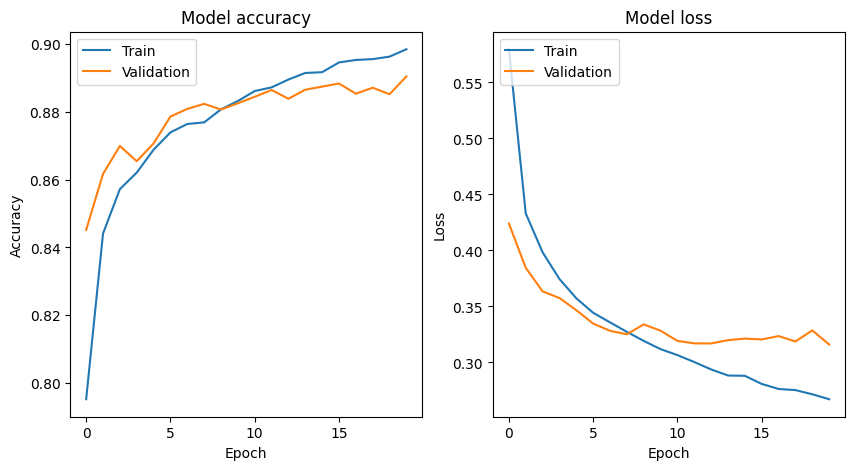

Test loss: 0.34755873680114746
Test accuracy: 0.8812999725341797
Best test accuracy achieved at epoch 20


In [ ]:
# Define callbacks for model checkpointing
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)

# Train the model
history = model.fit(X_train, Y_train,
                    batch_size=32, epochs=20,
                    verbose=1, validation_split=0.2, callbacks=[checkpoint])

# Plot accuracy and loss curves
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Load the best model
best_model = load_model('best_model.keras')

# Evaluate the best model on the test set
score = best_model.evaluate(X_test, Y_test, verbose=0)

# Print the best test accuracy and the corresponding epoch
print('Test loss:', score[0])
print('Test accuracy:', score[1])
# Find the epoch with the highest validation accuracy
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"Best test accuracy achieved at epoch {best_epoch+1}")

#### <font face="Verdana" color="green" size="+2">**3.4.2**
- What does the plot of accuracy and loss curves indicate about the model's learning process?
- Does the model exhibit overfitting or underfitting? Explain your reasoning. </font>

#### Observations:
1. **Accuracy (left plot):**
   - Training accuracy steadily improves and exceeds 0.90.
   - Validation accuracy improves initially but plateaus and slightly declines after approximately epoch 10–12.

2. **Loss (right plot):**
   - Training loss consistently decreases, indicating the model is learning on the training set.
   - Validation loss decreases initially but begins to plateau and slightly increase after some epochs.

#### Analysis:
The divergence between the training and validation curves indicates that the model begins to **overfit** after a certain number of epochs:
- The training accuracy continues to improve, while the validation accuracy plateaus and slightly declines.
- Training loss keeps decreasing, but validation loss increases, signaling that the model is failing to generalize well to unseen data.

#### Conclusion:
The model exhibits **overfitting** rather than underfitting. Overfitting occurs because the model performs very well on the training data but struggles to generalize to the validation data.

#### Recommendations to Address Overfitting:
- Use **early stopping** to halt training before overfitting begins.
- Apply regularization techniques such as **dropout** or **L2 regularization**.
- Increase the size of the training dataset or apply **data augmentation** techniques.


#### <font face="Verdana" color="green" size="+2">**3.5. Inspecting Model Predictions**

#### <font face="Verdana" color="green" size="+2">**3.5.1**
- Display at least 3 examples from the test set where the model predicts the correct label.
- Display at least 3 examples from the test set where the model predicts the wrong label. </font>

313/313 [==============================] - 2s 6ms/step


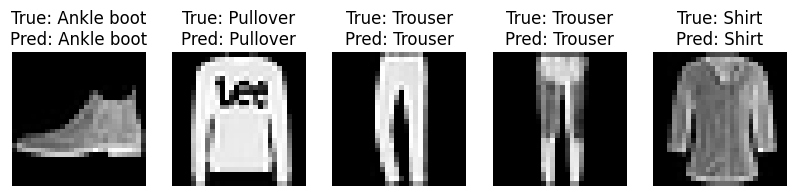

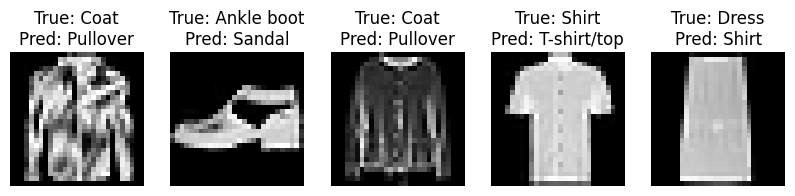

In [ ]:
# Predict on the test set using the best model
y_pred = best_model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)

# Display correctly predicted examples
correct_indices = np.where(y_pred_labels == y_test)[0]
plt.figure(figsize=(10, 5))
for i, idx in enumerate(correct_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {labels_map[y_test[idx]]}\nPred: {labels_map[y_pred_labels[idx]]}")
    plt.axis('off')
plt.show()


# Display incorrectly predicted examples
incorrect_indices = np.where(y_pred_labels != y_test)[0]
plt.figure(figsize=(10, 5))
for i, idx in enumerate(incorrect_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"True: {labels_map[y_test[idx]]}\nPred: {labels_map[y_pred_labels[idx]]}")
    plt.axis('off')
plt.show()

#### <font face="Verdana" color="green" size="+2">**3.5.2**
- What trends do you observe in the samples where the model predicts incorrectly?
- How can these observations inform improvements to the model?
</font>

## Observations of Incorrect Predictions

From the provided image, we can observe the following trends in the incorrectly classified samples:

1. **Similar Visual Features Between Classes**:
   - Some categories like "Ankle boot" and "Sandal" or "Coat" and "Pullover" share overlapping visual textures or shapes that might confuse the model.

2. **Low Image Resolution**:
   - The images have relatively low resolution, which could make it harder for the model to differentiate between fine details of different clothing items.

3. **Ambiguity in Certain Categories**:
   - Some samples (e.g., "T-shirt/top" predicted as "Shirt") suggest ambiguity between categories that have subtle differences in design.
---

## Suggestions for Model Improvements

1. **Data Augmentation**:
   - Introduce data augmentation techniques such as rotations, scaling, or brightness adjustments to improve the model’s robustness to variations.

2. **Higher Image Resolution**:
   - Train the model using higher-resolution images (if available) to capture more details in features.

3. **Class-Specific Augmentation**:
   - Augment under-represented classes like "Dress" to balance the dataset and improve model generalization.

4. **Ensemble Models**:
   - Combine predictions from multiple models with slightly different architectures or preprocessing pipelines to reduce individual biases.

5. **Use different architectures**:
   - CNN, For example?

<hr>





### **<font face="Courier New" color="blue" size="+3">Question 4 (Extra): Training and Optimizing a Deep Neural Network with Advanced Techniques (40 points)  </font>**

You are tasked with training a deep neural network to classify images from the CIFAR100 dataset. The dataset contains 60,000 color images (50,000 for training and 10,000 for testing) of size 32 × 32 pixels, across 100 classes. Load the dataset using `tf.keras.datasets.cifar100.load_data()`. To simplify, choose 10 specific classes for classification.

**For each parts that we deal with some results or plots, you should present your explanation about them!**

#### <font face="Verdana" color="green" size="+2">**4.1. Data Preparation (5 points)**



#### <font face="Verdana" color="green" size="+2">**4.1.1**


- Filter the CIFAR100 dataset to include only 10 classes of your choice.
- Normalize the image pixel values to the range **[0, 1]** and preprocess the data to flatten the images into vectors of size 3,072 `(32 × 32 × 3)`.

In [ ]:
# Load and filter CIFAR100 dataset
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

In [ ]:
# Choose 10 classes
selected_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Example classes

# Filter the dataset
train_indices = [i for i, label in enumerate(y_train) if label[0] in selected_classes]
test_indices = [i for i, label in enumerate(y_test) if label[0] in selected_classes]

x_train_filtered = x_train[train_indices]
y_train_filtered = y_train[train_indices]
x_test_filtered = x_test[test_indices]
y_test_filtered = y_test[test_indices]

# Normalize pixel values
x_train_filtered = x_train_filtered.astype('float32') / 255.0
x_test_filtered = x_test_filtered.astype('float32') / 255.0

# Flatten the images
x_train_flat = x_train_filtered.reshape(len(x_train_filtered), 3072)
x_test_flat = x_test_filtered.reshape(len(x_test_filtered), 3072)

#### <font face="Verdana" color="green" size="+2">**4.1.2**
* Why is it important to normalize input data in neural networks?
* What challenges arise when dealing with datasets that have many classes?</font>

### Importance of Normalizing Input Data in Neural Networks:
1. **Improved Convergence**: Neural networks converge faster during training when the input data is normalized. This is because normalization ensures that features have similar scales, reducing the risk of some features dominating the optimization process.
2. **Numerical Stability**: When inputs are not normalized, large values can cause numerical instability, particularly in deeper networks, leading to exploding or vanishing gradients.
3. **Consistent Activation**: Normalized inputs help activations across layers stay within a range that prevents saturation of activation functions, especially for functions like sigmoid or tanh.
4. **Fair Weight Updates**: Normalization ensures that weights are updated proportionally for all features, preventing bias in gradient-based optimization.

### Challenges with Datasets Having Many Classes:
1. **Class Imbalance**: Some classes may have significantly fewer samples than others, leading to biased model predictions towards dominant classes.
2. **High Dimensionality in Outputs**: For tasks like classification with many classes, the final layer's dimensionality increases, making the model computationally expensive and memory-intensive.
3. **Overfitting**: With many classes, the model may memorize the training data for majority classes rather than generalizing well, especially if data augmentation or regularization is not applied.
4. **Data Scarcity per Class**: As the number of classes increases, the average number of samples per class might decrease, reducing the model's ability to learn robust representations.
5. **Increased Complexity**: With more classes, distinguishing between similar ones becomes harder, requiring more sophisticated models or preprocessing techniques.



#### <font face="Verdana" color="green" size="+2">**4.2. Model Setup  (5 points)**

#### <font face="Verdana" color="green" size="+2">**4.2.1**

* Build a DNN with 10 hidden layers, each containing 128 neurons.
* Use **He initialization** and the **Swish** activation function.
* Ensure the output layer is a softmax layer with 10 neurons.

In [ ]:
# Build the model
def make_model(batch = False , opt ='adam'):
  model=Sequential()
  model.add(Dense(128, input_shape=(3072,), activation='swish' , kernel_initializer=he_normal()))
  if (batch):
    model.add(BatchNormalization())  # Add batch normalization
  for _ in range(9):
      model.add(Dense(128, activation='swish' , kernel_initializer=he_normal()))
      if (batch):
        model.add(BatchNormalization())  # Add batch normalization
  model.add(Dense(10, activation='softmax'))

  # Compile the model
  model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

  model.summary()
  return model

model = make_model()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 128)               393344    
                                                                 
 dense_9 (Dense)             (None, 128)               16512     
                                                                 
 dense_10 (Dense)            (None, 128)               16512     
                                                                 
 dense_11 (Dense)            (None, 128)               16512     
                                                                 
 dense_12 (Dense)            (None, 128)               16512     
                                                                 
 dense_13 (Dense)            (None, 128)               16512     
                                                                 
 dense_14 (Dense)            (None, 128)              

#### <font face="Verdana" color="green" size="+2">**4.2.2**
* How does the choice of activation function (e.g., Swish) affect model performance?
* Why is He initialization preferred for networks with activation functions like Swish or ReLU?</font>

### How does the choice of activation function (e.g., Swish) affect model performance?
The choice of activation function impacts the model's ability to learn complex patterns by influencing gradient flow, non-linearity, and convergence. Swish, for instance, often improves performance by enabling smoother gradient propagation and better optimization.

### What is Swish؟
Swish is an activation function defined as:
$$
\text{Swish}_{β}(x) = x \cdot \sigma(\beta x)
$$
where $\sigma(x)$ is the sigmoid function:
$$
\sigma(x) = \frac{1}{1 + e^{-\beta x}}
$$
![link text](https://doimages.nyc3.cdn.digitaloceanspaces.com/010AI-ML/content/images/2021/03/Screenshot-2021-03-25-at-12.32.44-PM.png)


### Why is He initialization preferred for networks with activation functions like Swish or ReLU?
**He initialization** is a method used to initialize the weights of neural networks, specifically designed for layers with ReLU (Rectified Linear Unit) activation functions. It helps to address the issue of vanishing/exploding gradients during the training process by ensuring that the weights are initialized with an appropriate variance.

The initialization formula is:

It samples each entry in $W^{[l]}$ from $N (0 , \sqrt{\frac{2}{size^{[l-1]}}})$
 where  $size^{[l-1]}$ is the number of units in the previous layer.

This scaling ensures that the output variance remains stable as the signal propagates through the layers, improving convergence during training.

He initialization is particularly useful when the ReLU activation function (or its variants like Leaky ReLU) and swish, is used since it accounts for the fact that only a portion of the neurons in a layer will be activated.




 #### <font face="Verdana" color="green" size="+2">**4.3.  Training with Optimizers and Callbacks (7 points)**

#### <font face="Verdana" color="green" size="+2">**4.3.1**

* Train the network using the **Adam** optimizer and an **early stopping** callback with a patience of 5 epochs.
* Experiment with at least three different **batch sizes** (e.g., 32, 64, 128). Compare the training time and accuracy using plots, and select the best batch size.

In [ ]:
# Experiment with different batch sizes
batch_sizes = [32, 64, 128]
results = {}
accuracies = {}
losses = {}

best_batch_size = None
best_accuracy = 0

for batch_size in batch_sizes:
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=5)
    model = make_model()
    # Train the model with current batch size and callbacks
    history = model.fit(x_train_flat, y_train_filtered,
                        batch_size=batch_size, epochs=50,  # Increased epochs for better observation
                        verbose=1, validation_split=0.2, callbacks=[early_stopping])
    # Store results
    results[batch_size] = history
    loss, accuracy = model.evaluate(x_test_flat, y_test_filtered, verbose=0)
    print(f"Test Accuracy for batch size {batch_size}: {accuracy}")
    accuracies[batch_size] = accuracy
    losses[batch_size] = loss
    if accuracy > best_accuracy:
      best_accuracy = accuracy
      best_batch_size = batch_size
    print(40 * '-')




Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_19 (Dense)            (None, 128)               393344    
                                                                 
 dense_20 (Dense)            (None, 128)               16512     
                                                                 
 dense_21 (Dense)            (None, 128)               16512     
                                                                 
 dense_22 (Dense)            (None, 128)               16512     
                                                                 
 dense_23 (Dense)            (None, 128)               16512     
                                                                 
 dense_24 (Dense)            (None, 128)               16512     
                                                                 
 dense_25 (Dense)            (None, 128)              

<Figure size 1500x500 with 0 Axes>

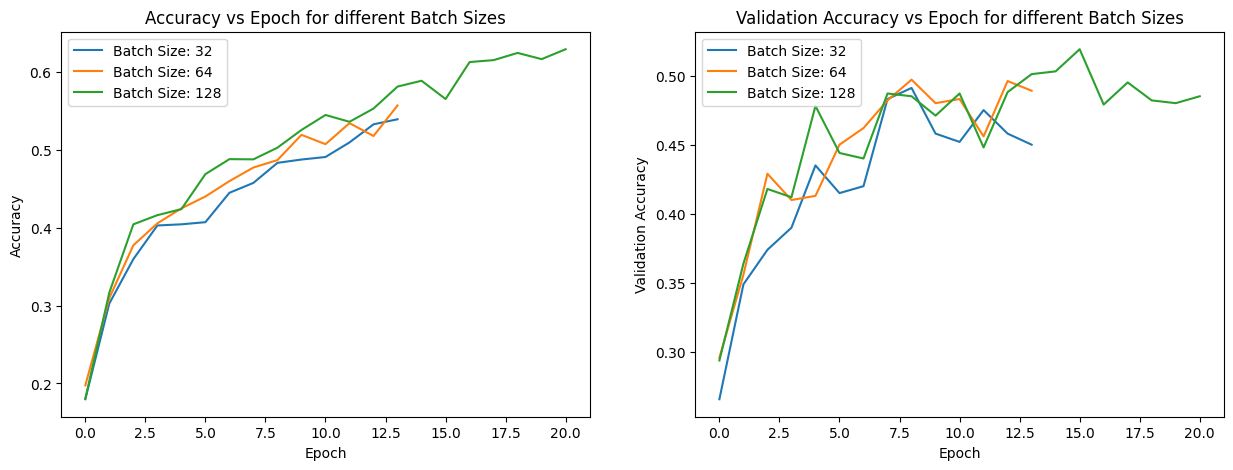

The best batch size is: 64


In [ ]:
# Plot accuracy curves for different batch sizes
plt.figure(figsize=(15, 5))

# Plot accuracy curves for different batch sizes
plt.figure(figsize=(15, 5))
plt.subplot(1, 2 , 1)
for batch_size, history in results.items():
    plt.plot(history.history['accuracy'], label=f'Batch Size: {batch_size}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch for different Batch Sizes')
plt.legend()

plt.subplot(1, 2, 2)
for batch_size, history in results.items():
    plt.plot(history.history['val_accuracy'], label=f'Batch Size: {batch_size}')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs Epoch for different Batch Sizes')
plt.legend()
plt.show()
# Select the best batch size based on the results

# Example selection: choose the batch size that gives the highest validation accuracy on the last epoch
print(f'The best batch size is: {best_batch_size}')

#### <font face="Verdana" color="green" size="+2">**4.3.2**
* How does the batch size influence training time and model accuracy?
* Why might smaller batch sizes lead to noisier gradients but better generalization?</font>

### Influence of Batch Size on Training Time and Model Accuracy

1. **Training Time**:
   - Smaller batch sizes lead to slower training because each batch is processed sequentially, resulting in more gradient updates per epoch.
   - Larger batch sizes reduce training time per epoch since more samples are processed in parallel, but fewer updates are made per epoch.

2. **Model Accuracy**:
   - Smaller batch sizes "often" result in better generalization and accuracy.
   - Larger batch sizes might lead to faster convergence but could overfit the training data and underperform on validation data.

---

### Why Smaller Batch Sizes Lead to Noisier Gradients but Better Generalization

- **Noisier Gradients**:
  - With smaller batches, each gradient update is computed using fewer samples, introducing variability in the direction of the gradients (gradient noise).
  - This noise can prevent the model from converging to sharp local minima, which might not generalize well.

- **Better Generalization**:
  - The noisier updates help the model explore a broader solution space, potentially finding flatter minima. Flatter minima are associated with better generalization because they are less sensitive to minor variations in the input data.
  - Additionally, smaller batch sizes inherently add a regularization effect due to this noise, which can improve the model's performance on unseen data.


#### <font face="Verdana" color="green" size="+2">**4.4. Batch Normalization and Gradient Clipping (7 points)**

#### <font face="Verdana" color="green" size="+2">**4.4.1**

</font>

* Add **batch normalization** to the model and compare the learning curves (training/validation accuracy and loss) with and without it.
* Implement **gradient clipping** with a clipvalue of 1.0. Discuss its effect on training stability and final performance.

In [ ]:
# --- Model with Batch Normalization ---
model_bn = make_model(batch=True)
base_model = make_model()

batch_size = 32 #Using best batch size from previous step. You can experiment here.


# Example training loop (adapt to your code)
history_bn = model_bn.fit(x_train_flat, y_train_filtered,
                          batch_size=batch_size, epochs=50,
                          verbose=1, validation_split=0.2)
history = model.fit(x_train_flat, y_train_filtered,
                          batch_size=batch_size, epochs=50,
                          verbose=1, validation_split=0.2)



Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_52 (Dense)            (None, 128)               393344    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dense_53 (Dense)            (None, 128)               16512     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_54 (Dense)            (None, 128)               16512     
                                                                 
 batch_normalization_2 (Bat  (None, 128)              

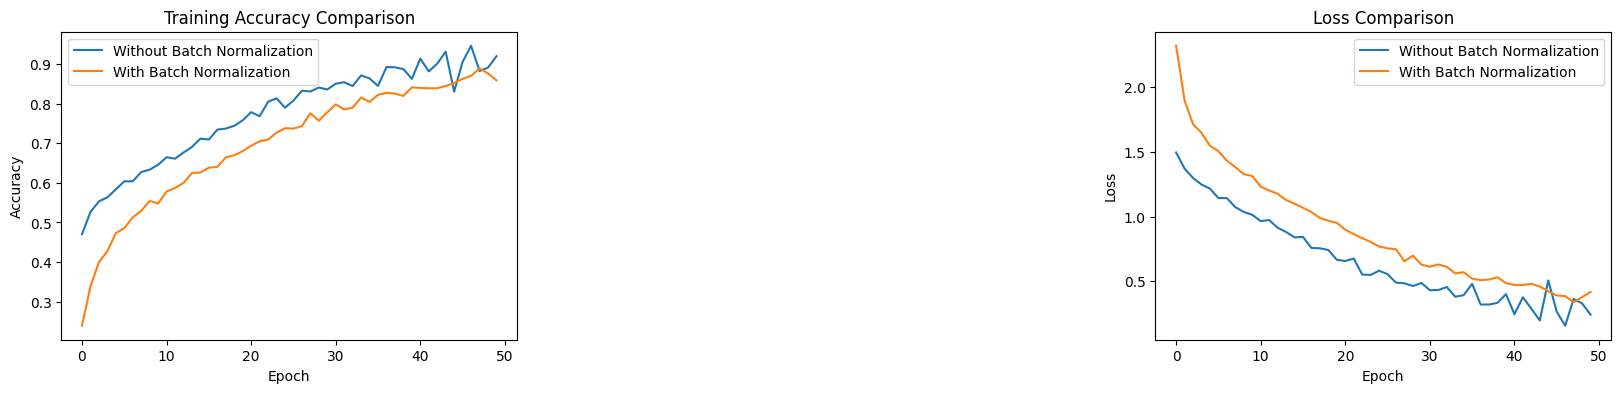

In [ ]:
def plot(h1 , h2 , l1 , l2):
  plt.figure(figsize=(20, 4))

  # Plot training accuracy
  plt.subplot(1, 3, 1)
  plt.plot(h1.history['accuracy'], label=l1)
  plt.plot(h2.history['accuracy'], label=l2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training Accuracy Comparison')
  plt.legend()

  # # Plot validation accuracy
  # plt.subplot(1, 3, 2)
  # plt.plot(h1.history['val_accuracy'], label=l1)
  # plt.plot(h2.history['val_accuracy'], label=l2)
  # plt.xlabel('Epoch')
  # plt.ylabel('Validation Accuracy')
  # plt.title('Validation Accuracy Comparison')
  # plt.legend()

  # Plot loss
  plt.subplot(1, 3, 3)
  plt.plot(h1.history['loss'], label=l1)
  plt.plot(h2.history['loss'], label=l2)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss Comparison')
  plt.legend()
  plt.show()
plot(history , history_bn  , 'Without Batch Normalization' , 'With Batch Normalization')


Batch normalization has a significant impact on the training and validation performance of the model, as observed in the provided learning curves.

**Training Accuracy:**

* Without batch normalization, the model achieves higher training accuracy initially but exhibits fluctuations during later epochs.
* With batch normalization, the training accuracy progresses more smoothly, stabilizing earlier and achieving a similar final accuracy.


**Training Loss:**

* Without batch normalization, training loss decreases steadily but with noticeable fluctuations.
* With batch normalization, the loss decreases faster in the early stages and stabilizes with fewer oscillations, showing more efficient learning.

**General Observations:**

* Batch normalization accelerates convergence, particularly during the initial training phase.
* It reduces fluctuations in both accuracy and loss, improving the stability of training and generalization.
* The final accuracy and loss are comparable for both models, but the smoother progression with batch normalization indicates better optimization dynamics.

![Image3](https://miro.medium.com/v2/resize:fit:2000/format:webp/1*VsN_9_AN2ji8hCZYSTTV0w.png)

#### Gradient Clipping

In [ ]:
# Compile the model with gradient clipping
optimizer = Adam(clipvalue=1.0) # Gradient clipping added here
model_adam = make_model(opt = optimizer)

history_adam = model_adam.fit(x_train_flat, y_train_filtered,
                        batch_size=batch_size, epochs=50,
                        verbose=1, validation_split=0.2)

# Evaluate the model
loss_adam, accuracy_adam = model_adam.evaluate(x_test_flat, y_test_filtered, verbose=0)
print(f"Test Accuracy with Batch Normalization and Gradient Clipping: {accuracy_adam}")

Model: "sequential_10"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_74 (Dense)            (None, 128)               393344    
                                                                 
 dense_75 (Dense)            (None, 128)               16512     
                                                                 
 dense_76 (Dense)            (None, 128)               16512     
                                                                 
 dense_77 (Dense)            (None, 128)               16512     
                                                                 
 dense_78 (Dense)            (None, 128)               16512     
                                                                 
 dense_79 (Dense)            (None, 128)               16512     
                                                                 
 dense_80 (Dense)            (None, 128)             

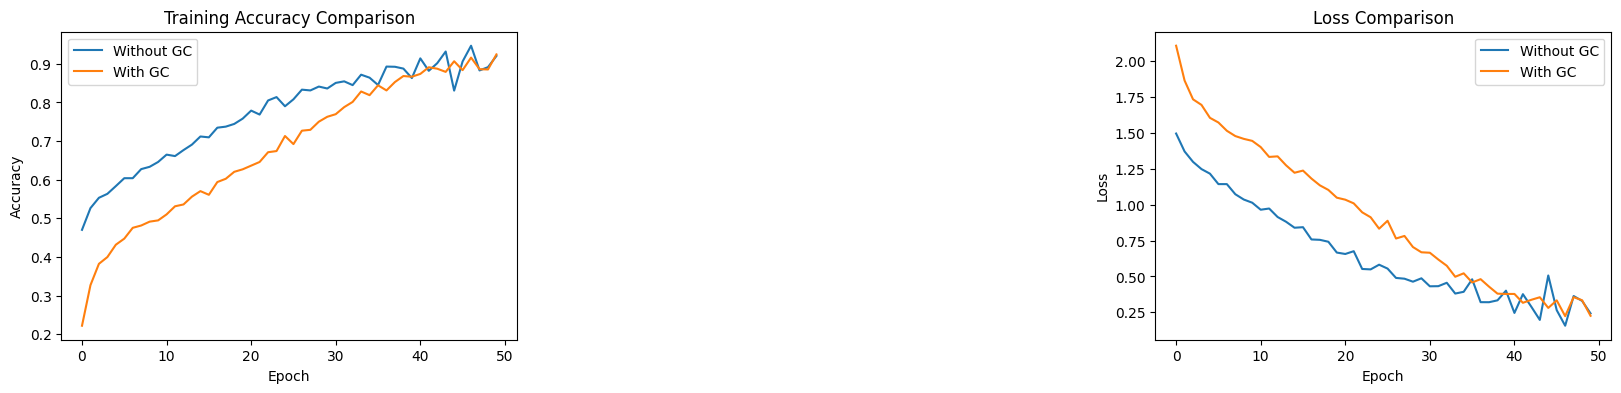

In [ ]:
plot(history , history_adam  , 'Without GC' , 'With GC')


## Comparison of Gradient Clipping (GC) with Clip Value 1.0

### 1. Training Accuracy
- **Without GC**: The model achieves higher training accuracy earlier in training but shows some fluctuations throughout the epochs.
- **With GC**: The training accuracy curve is smoother and more consistent, indicating improved training stability. However, the final training accuracy is slightly lower compared to the model without GC.

### 3. Training Loss
- **Without GC**: Training loss decreases steadily but with noticeable oscillations, especially in the early epochs.
- **With GC**: The loss decreases more smoothly, suggesting that gradient clipping helps to stabilize the optimization process. However, the final loss is similar for both cases.

### 4. Observations on Gradient Clipping
- Gradient clipping mitigates the effect of large gradients, which can destabilize training, especially in deep networks or when gradients explode.
- It improves the stability of both training and validation metrics, as seen in smoother curves.
- Although the model without GC achieves higher training accuracy, this could be indicative of overfitting, as GC provides a more stable and generalized performance.
- The final accuracy and loss values are comparable, but GC provides a more controlled optimization process.


In [ ]:
# Compile the model with gradient clipping
optimizer_both = Adam(clipvalue=1.0) # Gradient clipping added here
model_adam_batch = make_model(opt = optimizer_both , batch=True)


history_adam_batch = model_adam_batch.fit(x_train_flat, y_train_filtered,
                        batch_size=batch_size, epochs=50,
                        verbose=1, validation_split=0.2)

# Evaluate the model
loss_adam_batch, accuracy_adam_batch = model_adam_batch.evaluate(x_test_flat, y_test_filtered, verbose=0)
print(f"Test Accuracy with Batch Normalization and Gradient Clipping: {accuracy_adam_batch}")

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_85 (Dense)            (None, 128)               393344    
                                                                 
 batch_normalization_10 (Ba  (None, 128)               512       
 tchNormalization)                                               
                                                                 
 dense_86 (Dense)            (None, 128)               16512     
                                                                 
 batch_normalization_11 (Ba  (None, 128)               512       
 tchNormalization)                                               
                                                                 
 dense_87 (Dense)            (None, 128)               16512     
                                                                 
 batch_normalization_12 (Ba  (None, 128)             

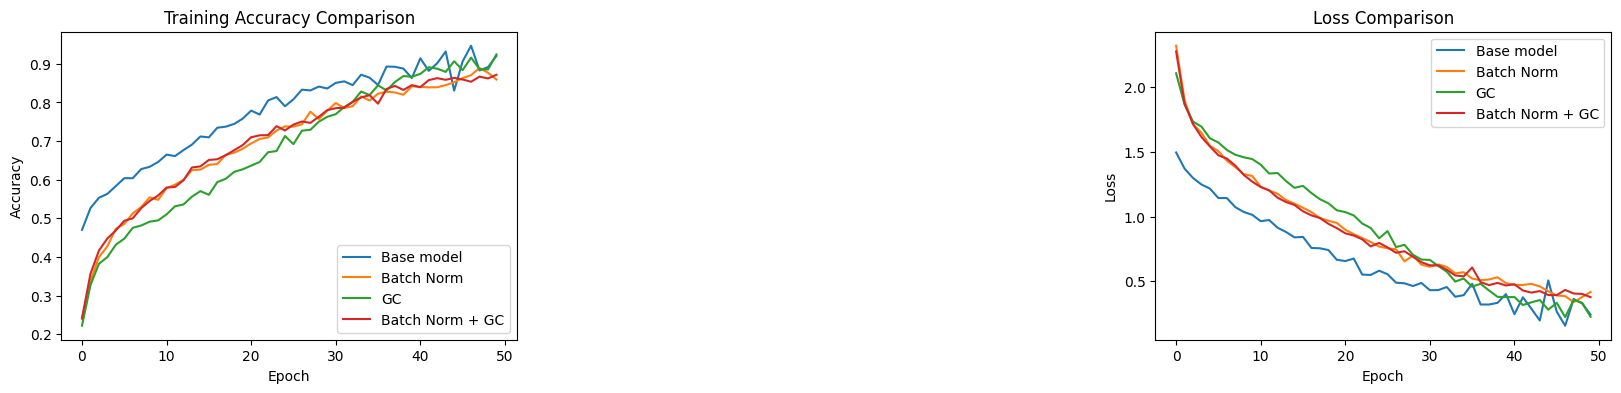

In [ ]:
plt.figure(figsize=(20, 4))

# Plot training accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label="Base model")
plt.plot(history_bn.history['accuracy'], label="Batch Norm")
plt.plot(history_adam.history['accuracy'], label="GC")
plt.plot(history_adam_batch.history['accuracy'], label="Batch Norm + GC")

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()


# Plot loss
plt.subplot(1, 3, 3)
plt.plot(history.history['loss'], label="Base model")
plt.plot(history_bn.history['loss'], label="Batch Norm")
plt.plot(history_adam.history['loss'], label="GC")
plt.plot(history_adam_batch.history['loss'], label="Batch Norm + GC")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison')
plt.legend()
plt.show()


#### <font face="Verdana" color="green" size="+2">**4.4.2**
* How does batch normalization improve training speed and model performance?
* What problems does gradient clipping solve in deep neural network training?
* Compare the combined effect of batch normalization and gradient clipping to using either technique alone.
</font>

### Batch Normalization
Batch normalization improves training speed by normalizing activations within layers, which allows the model to use higher learning rates. It mitigates issues like internal covariate shift, resulting in faster convergence and more stable optimization. Additionally, it acts as a regularizer, reducing overfitting and improving generalization.

### Gradient Clipping
Gradient clipping addresses exploding gradient problems during backpropagation by capping gradients to a fixed value. This stabilizes training, especially in deep networks, and prevents the optimizer from making erratic updates that could derail convergence.

### Combined Effect of Batch Normalization and Gradient Clipping
Using both batch normalization and gradient clipping combines their strengths. Batch normalization accelerates convergence and smooths learning, while gradient clipping ensures stability by controlling gradient magnitudes. Together, they create a more stable training process with improved convergence speed and generalization compared to using either technique alone.


#### <font face="Verdana" color="green" size="+2">**4.5. Advanced Regularization and Learning Rate Scheduling (10 points)**

#### <font face="Verdana" color="green" size="+2">**4.5.1**

</font>

* Use **SELU** activation and **alpha dropout** for regularization. Train the model and analyze its performance compared to the previous setup.
* Use **LR scheduling** and observe its impact on training convergence and final accuracy. Try to implement an schedular that is best for this problem. You can try impelement the schedulars you saw in the slides.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import AlphaDropout
from tensorflow.keras.optimizers.schedules import ExponentialDecay


tf.random.set_seed(42)
def make_model2(batch=False, opt='adam', selu=False, alpha_dropout=False):
    model = Sequential()
    if selu:
        model.add(Dense(128, input_shape=(3072,), activation='selu'))
    else:
        model.add(Dense(128, input_shape=(3072,), activation='swish'))

    if batch:
        model.add(BatchNormalization())
    if alpha_dropout:
      model.add(AlphaDropout(0.1))
    for _ in range(9):
        if selu:
            model.add(Dense(128, activation='selu'))
        else:
            model.add(Dense(128, activation='swish'))

        if batch:
            model.add(BatchNormalization())
        if alpha_dropout:
          model.add(AlphaDropout(0.1))
    model.add(Dense(10, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    model.summary()
    return model


# LR scheduler piecewise constant scheduling
def lr_scheduler(epoch):
  if epoch < 10:
    return 0.001
  elif epoch < 20:
    return 0.0003
  elif epoch < 30:
    return 0.0001
  elif epoch < 40:
    return 0.00003
  else:
    return 0.00001
optimizer = Adam(learning_rate=0.001)

# initial_learning_rate = 0.001
# lr_schedule = ExponentialDecay(
#     initial_learning_rate,
#     decay_steps=1000,
#     decay_rate=0.9,
# )
# optimizer = Adam(learning_rate=lr_schedule)


# Example usage with SELU and Alpha Dropout
model_selu = make_model2(selu=True, opt = optimizer , alpha_dropout=True)

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler)
# Train with LR scheduler and callbacks
history_selu = model_selu.fit(x_train_flat, y_train_filtered,
                             batch_size=32, epochs=50,
                             verbose=1, validation_split=0.2 , callbacks=[lr_callback] )


Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_107 (Dense)           (None, 128)               393344    
                                                                 
 alpha_dropout_10 (AlphaDro  (None, 128)               0         
 pout)                                                           
                                                                 
 dense_108 (Dense)           (None, 128)               16512     
                                                                 
 alpha_dropout_11 (AlphaDro  (None, 128)               0         
 pout)                                                           
                                                                 
 dense_109 (Dense)           (None, 128)               16512     
                                                                 
 alpha_dropout_12 (AlphaDro  (None, 128)             

In [ ]:
# Evaluate the model with SELU and AlphaDropout
test_loss_selu, test_acc_selu = model_selu.evaluate(x_test_flat, y_test_filtered, verbose=1)
print(f"Test accuracy with SELU and AlphaDropout: {test_acc_selu}")

32/32 [==============================] - 0s 3ms/step - loss: 2.4583 - accuracy: 0.4860
Test accuracy with SELU and AlphaDropout: 0.4860000014305115


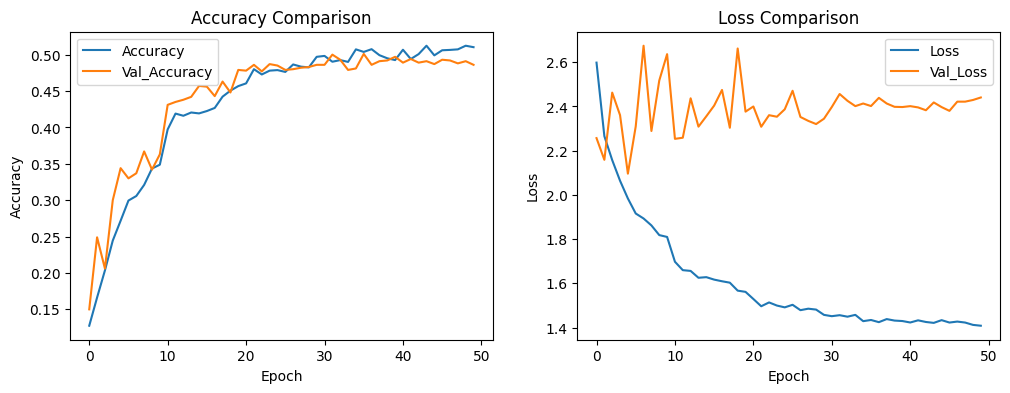

In [ ]:
def plot2(h1):
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(h1.history['accuracy'], label='Accuracy')
  plt.plot(h1.history['val_accuracy'], label='Val_Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Accuracy Comparison')
  plt.legend()

  # Plot loss
  plt.subplot(1, 2, 2)
  plt.plot(h1.history['loss'], label='Loss')
  plt.plot(h1.history['val_loss'], label='Val_Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Loss Comparison')
  plt.legend()
  plt.show()


plot2(history_selu)

#### <font face="Verdana" color="green" size="+2">**4.5.2**
* How does SELU activation differ from other activation functions like Mish?
* Compare the model's performance with and without alpha dropout. What differences do you notice?
* Provide a step-by-step analysis of the learning curves when using the LR scheduler.</font>



### SELU
![IMAGE4](https://miro.medium.com/v2/resize:fit:552/format:webp/1*8B58Q1pjYncoRmuKWWHJqg.png)


### MISH
![image5](https://miro.medium.com/v2/resize:fit:640/format:webp/1*fR8fs9P4vRn_nQd4Fb7OGA.png)

![image7](https://ml-explained.com/_ipx/sizes_xs:320px%20md:768px%20lg:1024px,w_1536,f_png/articles/activation-functions-explained/Mish_Function.png)


### SELU vs. Mish Activation
SELU (Scaled Exponential Linear Unit) is a self-normalizing activation function that automatically drives activations toward zero mean and unit variance during training. This property makes SELU ideal for deep networks with fully connected layers. In contrast, Mish is a smooth, non-monotonic activation function that combines features of ReLU and Swish, offering better gradient flow and performance in some tasks. SELU often requires careful use of specific initialization and architecture constraints (e.g., alpha dropout and scaled weights), while Mish is more flexible and widely applicable.

![image6](https://images.squarespace-cdn.com/content/v1/5f831c8e85a8ea3b5baabcbd/7f4cdc6f-798f-45db-831f-b0aaf7cb6f72/1*LIIoilXGJLdLpu_oTf_PSw.png?format=1500w)


### Alpha Dropout Comparison
Alpha Dropout is a type of Dropout that maintains the self-normalizing property. For an input with zero mean and unit standard deviation, the output of Alpha Dropout maintains the original mean and standard deviation of the input. Alpha Dropout goes hand-in-hand with SELU activation function, which ensures that the outputs have zero mean and unit standard deviation.

 Models with alpha dropout typically show more stable convergence and improved generalization compared to standard dropout. Without alpha dropout, training with SELU may lead to instability or slower convergence, especially in deeper networks.

### Learning Curves with an LR Scheduler
1. **Initial Phase**: At the start, the learning rate is typically high, leading to rapid decreases in training loss but also possible fluctuations in accuracy.
2. **Adjustment Phase**: As the LR scheduler reduces the learning rate, training stabilizes, with smoother accuracy improvements and more consistent loss reduction.
3. **Final Phase**: A lower learning rate results in finer optimization steps, leading to convergence. The validation metrics often improve during this phase as the model better generalizes.

By analyzing the learning curves, the scheduler's effect can be seen in smoother loss trends, reduced overfitting, and a balance between training and validation accuracy improvements.


#### <font face="Verdana" color="green" size="+2">**4.6. Optimizer Comparison (6 points)**

#### <font face="Verdana" color="green" size="+2">**4.6.1**

</font>

* Train the model using both **RMSprop** and **Nadam** optimizers.
* Compare their learning curves and final test accuracy.
* Provide an analysis of their strengths and weaknesses based on your observations.

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_118 (Dense)           (None, 128)               393344    
                                                                 
 alpha_dropout_20 (AlphaDro  (None, 128)               0         
 pout)                                                           
                                                                 
 dense_119 (Dense)           (None, 128)               16512     
                                                                 
 alpha_dropout_21 (AlphaDro  (None, 128)               0         
 pout)                                                           
                                                                 
 dense_120 (Dense)           (None, 128)               16512     
                                                                 
 alpha_dropout_22 (AlphaDro  (None, 128)             

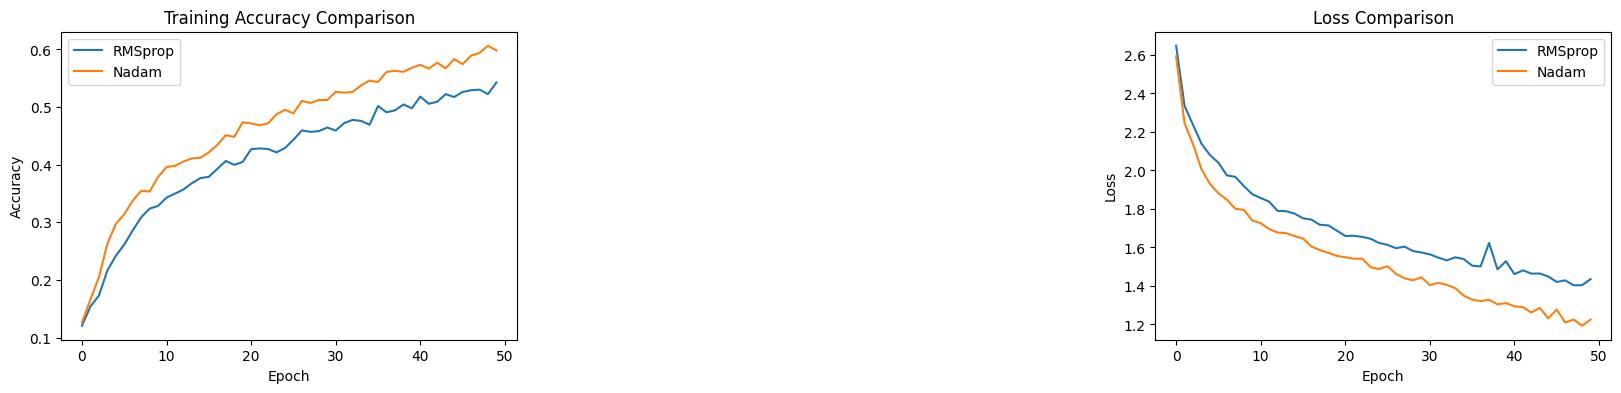

In [ ]:
from tensorflow.keras.optimizers import Adam, RMSprop, Nadam

# Train with RMSprop
optimizer_rmsprop = RMSprop(learning_rate=0.001)
model_rmsprop = make_model2(selu=True, opt =optimizer_rmsprop , alpha_dropout=True)
history_rmsprop = model_rmsprop.fit(x_train_flat, y_train_filtered, batch_size=32, epochs=50, verbose=1, validation_split=0.2)

# Train with Nadam
optimizer_nadam = Nadam(learning_rate=0.001)
model_nadam = make_model2(selu=True, opt=optimizer_nadam,  alpha_dropout=True)
history_nadam = model_nadam.fit(x_train_flat, y_train_filtered, batch_size=32, epochs=50, verbose=1, validation_split=0.2)

# Plot comparison
plot(history_rmsprop, history_nadam, "RMSprop", "Nadam")

#### <font face="Verdana" color="green" size="+2">**4.6.2**
* What are the main differences between RMSprop and Nadam optimizers?
* Present and interpret the learning curves (training/validation loss and accuracy) for each optimizer.
* Which optimizer performed better for this task, and why? What insights can you provide regarding their behavior?</font>



### RMSprop vs. Nadam Optimizers

![im](https://wiki.cloudfactory.com/media/pages/docs/mp-wiki/solvers-optimizers/rmsprop/3d95bb0387-1684131968/contour.webp)


#### Differences Between RMSprop and Nadam
RMSprop is an adaptive learning rate optimizer that adjusts learning rates based on recent gradient magnitudes, making it effective for handling non-stationary objectives. Nadam combines the benefits of Adam and Nesterov momentum, offering better gradient updates by incorporating lookahead gradient estimates. Nadam often provides smoother convergence and faster training in some cases.

#### Learning Curve Comparison
- **Training Accuracy**: Nadam demonstrates faster convergence with higher accuracy early in training. RMSprop shows a slower but steady improvement in training accuracy over time.
- **Validation Accuracy**: Nadam consistently outperforms RMSprop in validation accuracy, showing smoother and higher peaks. RMSprop exhibits more fluctuations and slightly lower generalization.
- **Loss**: Both optimizers reduce training loss effectively, but Nadam converges faster, reaching a lower loss earlier. RMSprop lags slightly, with more gradual loss reduction.

#### Performance and Insights
- **Better Performer**: Nadam outperformed RMSprop in both training and validation metrics. Its ability to combine momentum and adaptive learning rate strategies leads to faster convergence and better generalization.
- **Strengths**:
  - Nadam: Faster convergence, smoother training, and higher accuracy make it ideal for this task.
  - RMSprop: Robust and reliable for handling complex landscapes but slower in convergence.
- **Weaknesses**:
  - Nadam: May be sensitive to hyperparameters, requiring tuning for best results.
  - RMSprop: Slower convergence and less competitive generalization.

#### Conclusion
Nadam is the better optimizer for this task due to its faster convergence and improved performance on validation accuracy. Its ability to leverage momentum and adaptive learning rate strategies makes it a stronger choice for tasks requiring efficient and stable training.


<hr>

### **<font face="Courier New" color="blue" size="+3">Question 5 (Extra): Key Insights into Neural Network Initialization and Optimization Techniques(8 points)</font>**

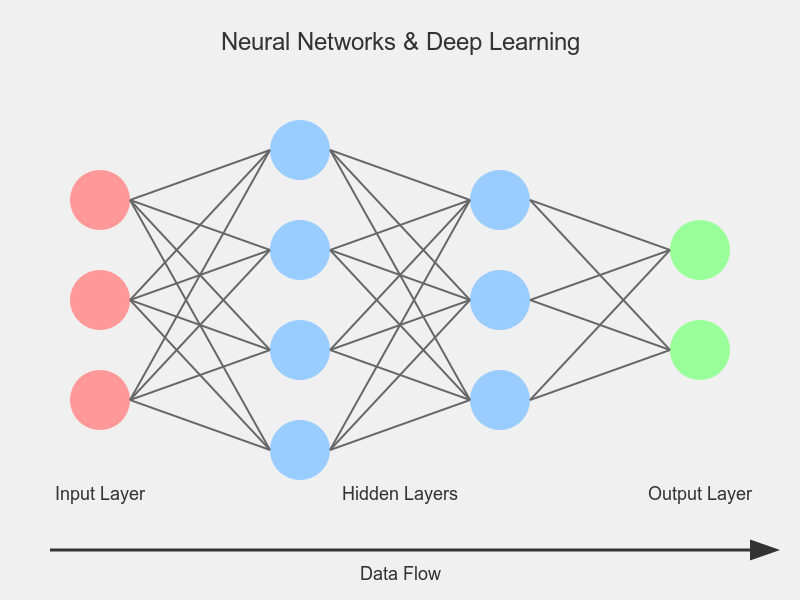

#### <font face="Verdana" color="green" size="+2">**5.1**
Momentum in SGD accelerates convergence but requires careful tuning. Analyze the effect of setting the momentum parameter too close to 1 (e.g., 0.99999). Discuss its impact on training dynamics.
</font>

### What Does Momentum Do in SGD?

Momentum in SGD helps accelerate convergence by smoothing the updates during optimization. It achieves this by incorporating an exponentially weighted moving average of past gradients into the current parameter update.

The update rule with momentum is:

$$
v_t = \beta v_{t-1} + (1 - \beta) g_t
$$
$$
\theta_t = \theta_{t-1} - \eta v_t
$$

Where:
- $ v_t $: Velocity (accumulated gradient)
- $ \beta $: Momentum coefficient (e.g., 0.9)
- $ g_t $: Gradient at step $ t $
- $ \eta $: Learning rate
- $ \theta_t $: Parameter values

### Key Effects:
1. **Smoothing Updates**: Momentum reduces oscillations in high-curvature regions (e.g., ravines) by dampening abrupt gradient changes.
2. **Acceleration**: It speeds up movement in consistent gradient directions, enabling faster traversal of flat regions in the loss surface.
3. **Noise Reduction**: By averaging past gradients, momentum mitigates the effect of noisy or fluctuating gradients, improving stability.

In essence, momentum helps the optimizer maintain a direction toward convergence, especially in challenging loss landscapes with noise or high curvature.


### Effect of Setting Momentum Close to 1 (e.g., 0.99999)

1. **Acceleration of Convergence**: High momentum accumulates past gradients, enabling faster traversal of flat regions or elongated valleys in the loss surface.

2. **Overshooting**: Excessive momentum can cause updates to overshoot the optimal point, leading to oscillations or divergence, especially with higher learning rates.

3. **Reduced Gradient Sensitivity**: The optimizer prioritizes past gradients, which may slow adaptation to sudden changes in the loss landscape.

4. **Instability**: High momentum can induce oscillations or instability in training, particularly in regions with high curvature.

5. **Practical Implications**: Balancing high momentum requires careful tuning of the learning rate. A value close to 1 should generally be avoided unless combined with low learning rates and specific problem-dependent adjustments.


#### <font face="Verdana" color="green" size="+2">**5.2**
Dropout is a popular regularization technique, but it affects training and inference differently. Analyze the impact of standard dropout and MC dropout on training time, generalization, and inference speed. When is MC dropout preferred over standard dropout, and why?
</font>

**MC Dropout (Monte Carlo Dropout):**  
MC Dropout is a technique used to estimate model uncertainty in neural networks. It involves applying dropout during both training and testing phases and performing multiple stochastic forward passes. By analyzing the variance in predictions, MC Dropout provides a measure of uncertainty.

**Difference from Simple Dropout:**  
- Simple dropout is applied only during training to prevent overfitting, while MC Dropout uses it during testing to simulate a Bayesian approximation.  
- Simple dropout focuses on improving generalization, whereas MC Dropout estimates uncertainty.

**Difference from Alpha Dropout:**  
- Alpha Dropout is designed for self-normalizing neural networks (e.g., SELU activation) to maintain the mean and variance.  
- Unlike MC Dropout, Alpha Dropout isn't used for uncertainty estimation.






### Analysis of Standard Dropout and MC Dropout





#### **1. Standard Dropout**
- **Training Time**: Standard dropout randomly drops a fraction of neurons during training, effectively increasing the number of iterations required for convergence as the model learns a stochastic subset of features at each step.
- **Generalization**: By preventing co-adaptation of neurons, it acts as a regularizer, improving the model's ability to generalize to unseen data.
- **Inference Speed**: At inference, dropout is not applied. Instead, the weights are scaled by the dropout rate, resulting in faster inference since no randomness is introduced.

#### **2. MC Dropout**
- **Training Time**: MC (Monte Carlo) dropout uses the same process as standard dropout during training, so the training time impact is similar.
- **Generalization**: Like standard dropout, it improves generalization during training. However, its primary use lies in uncertainty quantification during inference, as it generates a distribution of predictions.
- **Inference Speed**: MC dropout applies dropout during inference, requiring multiple stochastic forward passes to estimate uncertainty. This significantly increases inference time compared to standard dropout.

---

### **When is MC Dropout Preferred?**
- **Uncertainty Quantification**: MC dropout is used when the model needs to estimate prediction uncertainty, such as in medical diagnosis, autonomous driving, or active learning.
- **Out-of-Distribution Detection**: The variability in predictions provided by MC dropout helps detect inputs dissimilar to the training data.
- **Bayesian Approximation**: MC dropout acts as a practical approximation of Bayesian inference in neural networks, providing probabilistic outputs.

---

### **Comparison Summary**

| Aspect            | Standard Dropout              | MC Dropout                        |
|--------------------|-------------------------------|-----------------------------------|
| **Training Time**  | Increased (due to stochastic updates) | Similar to standard dropout     |
| **Generalization** | Effective regularization      | Same as standard dropout         |
| **Inference Speed**| Fast (no dropout applied)     | Slow (multiple forward passes)   |
| **Use Case**       | Regularization during training| Uncertainty estimation at inference |

**MC dropout is preferred when uncertainty estimation is critical, despite its higher inference cost.**


#### <font face="Verdana" color="green" size="+2">**5.3**
- What is the problem that Glorot initialization?
- Is it OK to initialize all the weights to the same value as long as that value is selected randomly using He initialization?
- Is it OK to initialize the bias terms to 0?
</font>

**Formula for Glorot Initialization (Xavier Initialization):**  

The Glorot initialization ensures that the variance of activations remains consistent across layers. The weights are initialized by sampling from a uniform or normal distribution with the following limits:

For **Uniform Distribution**:  
$$
W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}, \sqrt{\frac{6}{n_{\text{in}} + n_{\text{out}}}}\right)
$$

For **Normal Distribution**:  
$$
W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}} + n_{\text{out}}}\right)
$$

Where:  
- $n_{\text{in}} $: Number of input units to the layer.  
- $ n_{\text{out}} $: Number of output units from the layer.


### 1. **Problem Addressed by Glorot Initialization**

Glorot initialization (also known as Xavier initialization) addresses the issue of vanishing and exploding gradients in deep networks. When weights are initialized too large or too small, gradients can either vanish or explode as they are backpropagated, making learning slow or unstable. Glorot initialization sets the weights according to a distribution with a variance that depends on the number of input and output units of a layer. This helps maintain a balance in the scale of gradients, improving convergence and stability during training.

### 2. **Initializing All Weights to the Same Value Using He Initialization**

No, it is not ideal to initialize all weights to the same value, even if that value is selected randomly using He initialization. He initialization is designed to create a variance in the weights, taking into account the number of input units per neuron. Initializing all weights to the same value would prevent neurons from learning different features, causing symmetry problems and leading to ineffective training. Each weight should be initialized independently to break symmetry and allow each neuron to learn different patterns.

For **Uniform Distribution**:  
$$
W \sim U\left(-\sqrt{\frac{6}{n_{\text{in}}}}, \sqrt{\frac{6}{n_{\text{in}}}}\right)
$$

For **Normal Distribution**:  
$$
W \sim \mathcal{N}\left(0, \frac{2}{n_{\text{in}}}\right)
$$

Where:  
- $ n_{\text{in}} $: Number of input units to the layer.


### 3. **Initializing Bias Terms to 0**

Yes, it is generally OK to initialize the bias terms to 0. In fact, initializing biases to zero is a common practice, as biases do not have the same risk of causing vanishing or exploding gradients as weights. Starting with zero biases ensures that the model does not have a predefined bias in its outputs, allowing the network to learn the appropriate bias values during training. However, in some cases, small positive values are used for biases, especially in ReLU activations, to ensure neurons are activated early in the training.



#### <font face="Verdana" color="green" size="+2">AI Disclaimer

Promt: "give me a paragraph that states I have used gemini as AI assistant for this assingment. Make sure to include a sentence that this confess is also generated by gemini. Finally, ask Lord for forgiveness."

Result:

"In the spirit of transparency and academic integrity, I wish to disclose that I have utilized Google's Gemini AI assistant for various aspects of this assignment, including code generation, data analysis, and answering questions. I have diligently reviewed and critically evaluated all content generated by Gemini, ensuring its accuracy and incorporating my own understanding and insights to ensure the integrity and originality of the work. ***It is important to acknowledge that this very statement regarding the use of Gemini was also generated with the assistance of Gemini***. I humbly beseech the Lord for forgiveness for any shortcomings or unintended errors that may have arisen from this reliance on AI. May the lord forgive all of us."

